In [300]:
import numpy as np
import matplotlib.pyplot as plt

# Opg 5.1

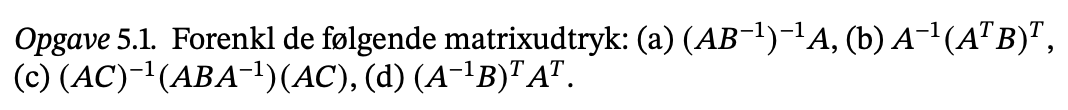

## (a)

Brug at: $(AB)^{-1} = B^{-1}A^{-1}$

$$(AB^{-1})^{-1} A = BA^{-1}A = BI_n = B$$

## (b)

$$A^{-1}(A^TB)^T = A^{-1}B^TA$$

## (c)

$$(AC)^{-1}(ABA^{-1})(AC) = C^{-1}A^{-1}ABA^{-1}AC = C^{-1}I_nBI_nC = C^{-1} B C$$

## (d)

$$(A^{-1} B)^T A^T = B^T (A^{-1})^T A^T$$

# Opg 5.2

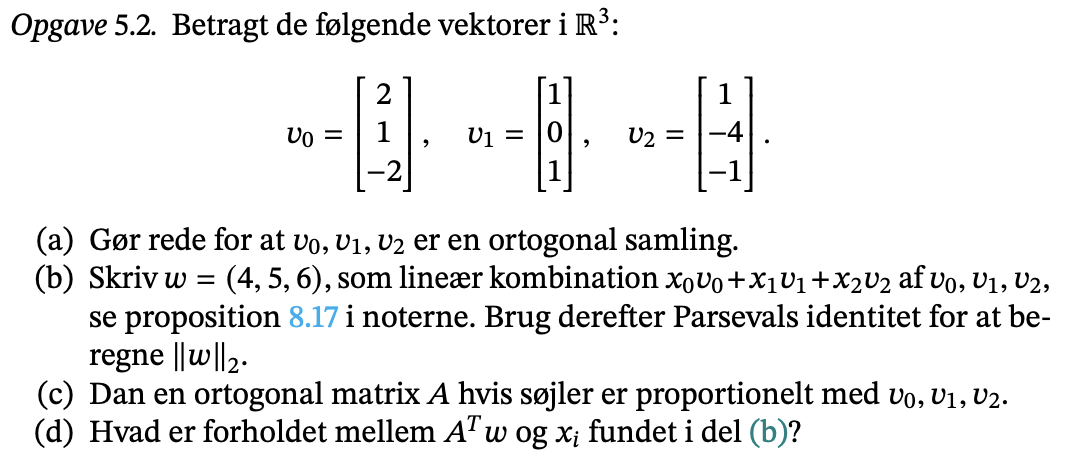

## (a)

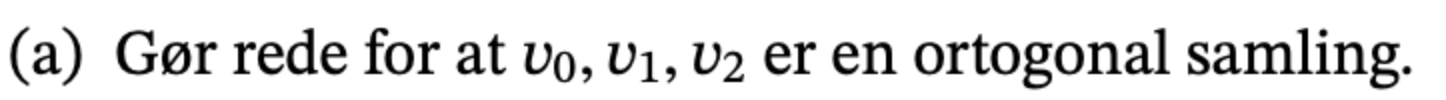

In [301]:
# Hvis grammatricen er en "vægtet" identitets matrice, så må det være en ortogonal samling:

v0 = np.array([2, 1, -2], dtype=float) [:, np.newaxis]
v1 = np.array([1, 0, 1], dtype=float) [:, np.newaxis]
v2 = np.array([1, -4, -1], dtype=float) [:, np.newaxis]

A = np.hstack([v0, v1, v2])

G = A.T @ A

G, A

(array([[ 9.,  0.,  0.],
        [ 0.,  2.,  0.],
        [ 0.,  0., 18.]]),
 array([[ 2.,  1.,  1.],
        [ 1.,  0., -4.],
        [-2.,  1., -1.]]))

Samlingen er altså ortogonal

## (b)

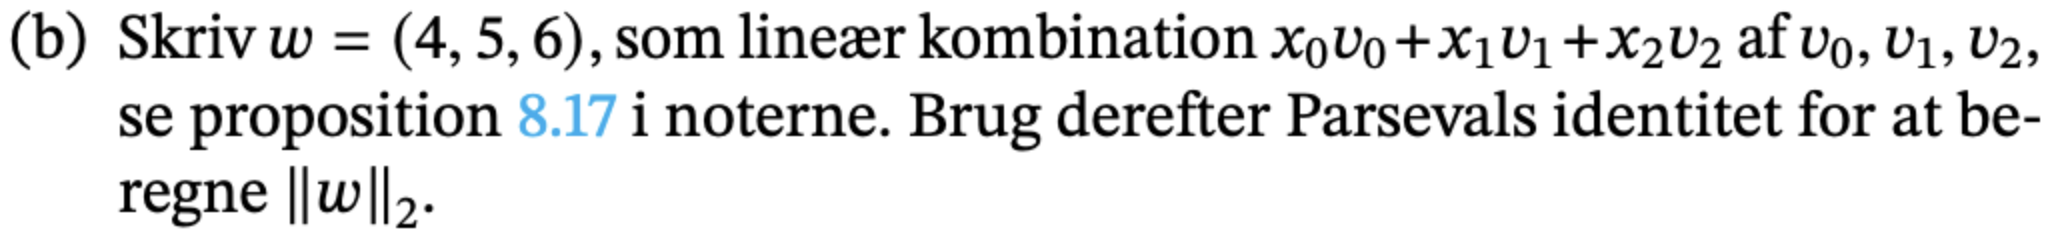

Man kan opstille et ligningssystem og løse det for at bestemme en linear kombination:

$$A \begin{bmatrix} x_0 \\ x_1 \\ x_2 \end{bmatrix} = w$$

Her er $A$ matricen som blev bestemt i koden ovenfor.

Dette løses blot i python:

In [302]:
w = np.array([4, 5, 6], dtype=float) [:, np.newaxis]

x = np.linalg.solve(A, w)

x

array([[ 0.11111111],
       [ 5.        ],
       [-1.22222222]])

In [303]:
x[0] * v0 + x[1] * v1 + x[2] * v2

array([[4.],
       [5.],
       [6.]])

Jeg beregner nu $|w|_0$ vha parsevals identitet:

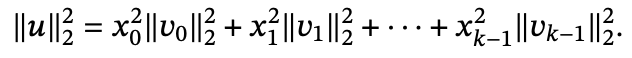

In [304]:
# Beregner ||u||_2^2

wnorm22 = 0

for i in range(3):
    wnorm22 += x[i]**2 * np.vdot(A[:, i], A[:, i])
    
wnorm2 = np.sqrt(wnorm22)

wnorm2, np.linalg.norm(w)

(array([8.77496439]), 8.774964387392123)

## (c)

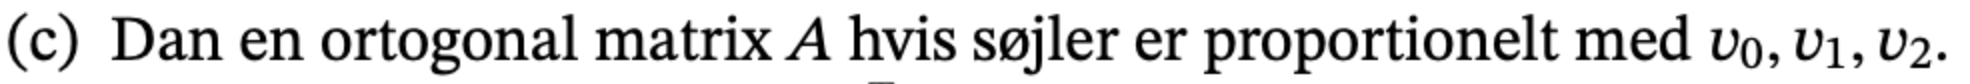

Jeg tager blot og finder enhedsvektorerne for vektorerne og bruger dem som søjler i $A$:

In [305]:
Aorto = np.hstack([v0/np.linalg.norm(v0), v1/np.linalg.norm(v1), v2/np.linalg.norm(v2)])

Aorto

array([[ 0.66666667,  0.70710678,  0.23570226],
       [ 0.33333333,  0.        , -0.94280904],
       [-0.66666667,  0.70710678, -0.23570226]])

## (d)

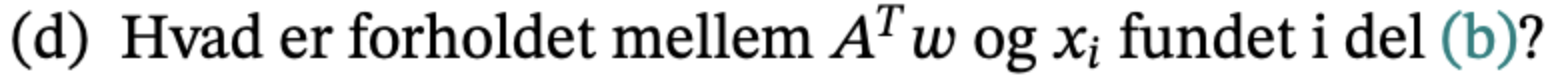

Forholdet mellem dem er at $(A^T w)_i = ||v_i||_2 x_i$

In [306]:
Aorto.T @ w, x

(array([[ 0.33333333],
        [ 7.07106781],
        [-5.18544973]]),
 array([[ 0.11111111],
        [ 5.        ],
        [-1.22222222]]))

Dette giver også mening hvis man tænker på det ift ligningssystemet.

# Opg 5.3

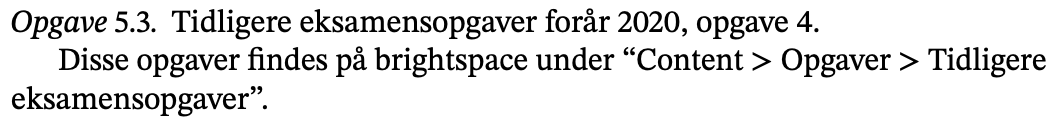

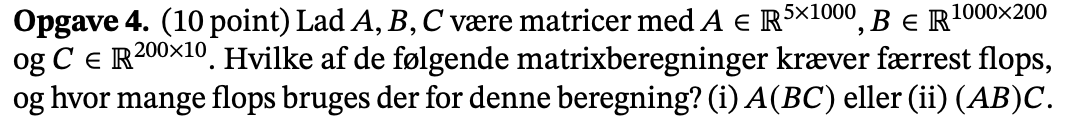

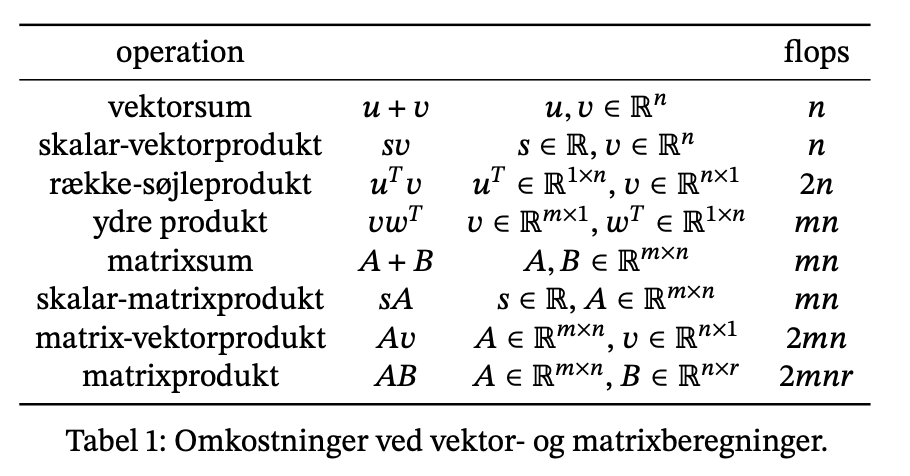

### (i)

$$A(BC)$$

Her bruges der først $2 * 1000 * 200 * 10 = 4000000 flops$.

Dernæst bruges der: $2 * 5 * 1000 * 10 = 100000 flops$

Dermed bruges der i alt $4100000 flops$.

### (ii)

$$(AB)C$$

Her bruges først: $2 * 5 * 1000 * 200 = 2000000 flops$

Dernæst bruges der: $2 * 5 * 200 * 10 = 20000 flops$

Dermed bruges der i alt $2020000 flops$.

Altså er (ii) den bedste metode.

## Opg 5.4

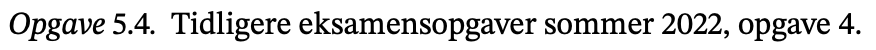

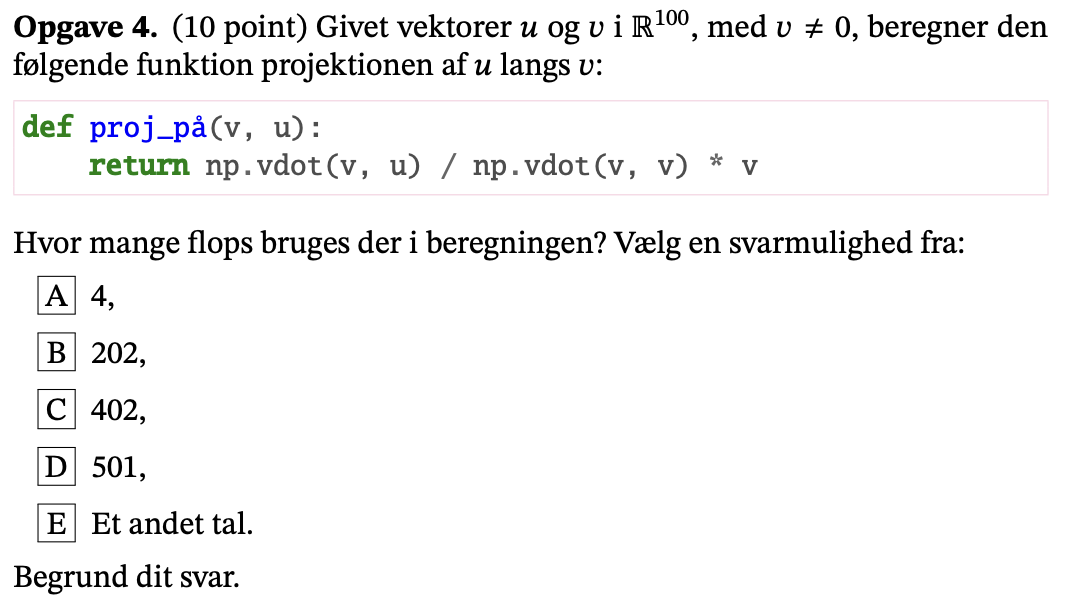

Hvert prik produkt bruger $2*n = 2 * 100 = 200 flops$. Dernæst bruges der så $1 flop$ på en division, og $n = 100 flop$ på en vektorscalar multiplikation.

I alt bruges der $501 flops$, og dermed er svaret $D$.

# Opg 5.5

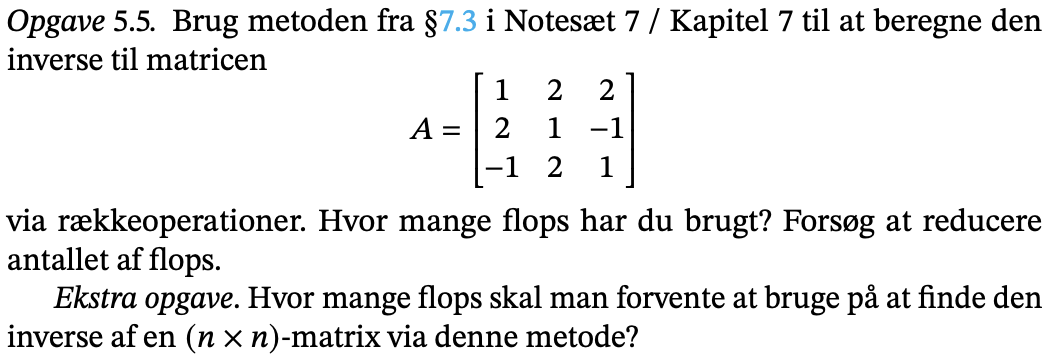

In [307]:
A = np.array([[1, 2, 2], 
              [2, 1, -1],
              [-1, 2, 1]], dtype=float)

AI = np.hstack([A, np.eye(3)])

AI

array([[ 1.,  2.,  2.,  1.,  0.,  0.],
       [ 2.,  1., -1.,  0.,  1.,  0.],
       [-1.,  2.,  1.,  0.,  0.,  1.]])

In [308]:
AI[1, :] -= 2 * AI[0, :]

AI

array([[ 1.,  2.,  2.,  1.,  0.,  0.],
       [ 0., -3., -5., -2.,  1.,  0.],
       [-1.,  2.,  1.,  0.,  0.,  1.]])

In [309]:
AI[2, :] += 1 * AI[0, :]

AI

array([[ 1.,  2.,  2.,  1.,  0.,  0.],
       [ 0., -3., -5., -2.,  1.,  0.],
       [ 0.,  4.,  3.,  1.,  0.,  1.]])

In [310]:
AI[1, :] /= -3

AI

array([[ 1.        ,  2.        ,  2.        ,  1.        ,  0.        ,
         0.        ],
       [-0.        ,  1.        ,  1.66666667,  0.66666667, -0.33333333,
        -0.        ],
       [ 0.        ,  4.        ,  3.        ,  1.        ,  0.        ,
         1.        ]])

In [311]:
AI[2, :] -= 4 * AI[1, :]

AI

array([[ 1.        ,  2.        ,  2.        ,  1.        ,  0.        ,
         0.        ],
       [-0.        ,  1.        ,  1.66666667,  0.66666667, -0.33333333,
        -0.        ],
       [ 0.        ,  0.        , -3.66666667, -1.66666667,  1.33333333,
         1.        ]])

In [312]:
AI[0, :] -= 2 * AI[1, :]

AI

array([[ 1.        ,  0.        , -1.33333333, -0.33333333,  0.66666667,
         0.        ],
       [-0.        ,  1.        ,  1.66666667,  0.66666667, -0.33333333,
        -0.        ],
       [ 0.        ,  0.        , -3.66666667, -1.66666667,  1.33333333,
         1.        ]])

In [313]:
AI[2, :] /= -11/3

AI

array([[ 1.        ,  0.        , -1.33333333, -0.33333333,  0.66666667,
         0.        ],
       [-0.        ,  1.        ,  1.66666667,  0.66666667, -0.33333333,
        -0.        ],
       [-0.        , -0.        ,  1.        ,  0.45454545, -0.36363636,
        -0.27272727]])

In [314]:
AI[1, :] -= 5/3 * AI[2, :]

AI

array([[ 1.00000000e+00,  0.00000000e+00, -1.33333333e+00,
        -3.33333333e-01,  6.66666667e-01,  0.00000000e+00],
       [ 0.00000000e+00,  1.00000000e+00, -4.44089210e-16,
        -9.09090909e-02,  2.72727273e-01,  4.54545455e-01],
       [-0.00000000e+00, -0.00000000e+00,  1.00000000e+00,
         4.54545455e-01, -3.63636364e-01, -2.72727273e-01]])

In [315]:
AI[0, :] += 4/3 * AI[2, :]

AI

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         2.72727273e-01,  1.81818182e-01, -3.63636364e-01],
       [ 0.00000000e+00,  1.00000000e+00, -4.44089210e-16,
        -9.09090909e-02,  2.72727273e-01,  4.54545455e-01],
       [-0.00000000e+00, -0.00000000e+00,  1.00000000e+00,
         4.54545455e-01, -3.63636364e-01, -2.72727273e-01]])

In [316]:
AI[:, 0:3]

array([[ 1.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  1.0000000e+00, -4.4408921e-16],
       [-0.0000000e+00, -0.0000000e+00,  1.0000000e+00]])

In [317]:
# A invers angives

Ainv = AI[:, 3:6]

Ainv, np.linalg.inv(A)

(array([[ 0.27272727,  0.18181818, -0.36363636],
        [-0.09090909,  0.27272727,  0.45454545],
        [ 0.45454545, -0.36363636, -0.27272727]]),
 array([[ 0.27272727,  0.18181818, -0.36363636],
        [-0.09090909,  0.27272727,  0.45454545],
        [ 0.45454545, -0.36363636, -0.27272727]]))

Generelt vil det koste

$$\color{red} \text{Kig lige på denne og få den lavet færdig}$$

# Opg 5.6

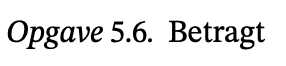

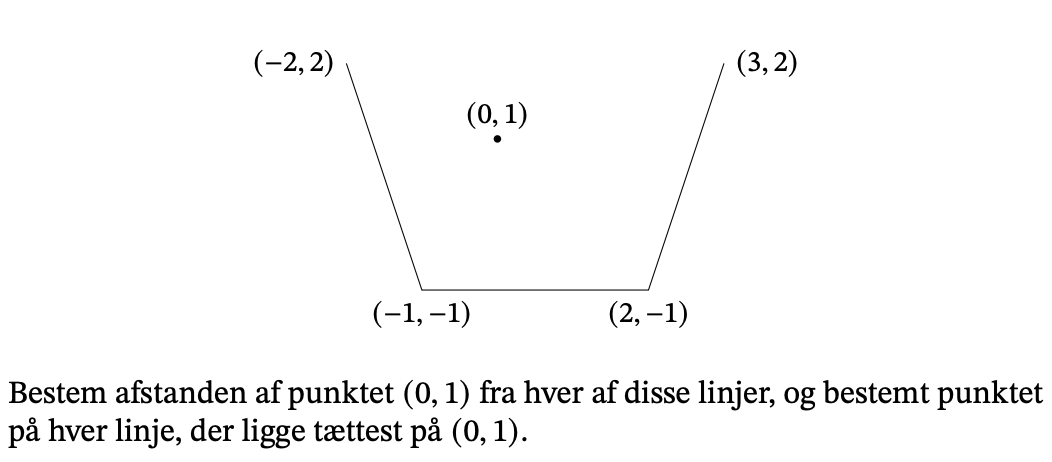

In [318]:
# Jeg starter med at definere alle linjer og punktet p

p = np.array([0, 1])

l1 = np.array([-1, -1]) - np.array([-2, 2])
l2 = np.array([2, -1]) - np.array([-1,-1])
l3 = np.array([3, 2]) - np.array([2,-1])

piftl1 = p - np.array([-2, 2])
piftl2 = p - np.array([-1, -1])
piftl3 = p - np.array([2, -1])

print(l1, l2, l3) 
print(piftl1, piftl2, piftl3)

[ 1 -3] [3 0] [1 3]
[ 2 -1] [1 2] [-2  2]


In [319]:
# Jeg bestemmer nu puntkerne på hver linje som ligger tættest på punktet

prl1p = np.vdot(piftl1, l1)/np.vdot(l1, l1) * l1
prl2p = np.vdot(piftl2, l2)/np.vdot(l2, l2) * l2
prl3p = np.vdot(piftl3, l3)/np.vdot(l3, l3) * l3

prl1piftori = prl1p + np.array([-2, 2])
prl2piftori = prl2p + np.array([-1, -1])
prl3piftori = prl3p + np.array([2, -1])

print("Dette er punkterne på linjerne fra venstre til højre", prl1piftori, prl2piftori, prl3piftori)

prl1p, prl2p, prl3p

Dette er punkterne på linjerne fra venstre til højre [-1.5  0.5] [ 0. -1.] [2.4 0.2]


(array([ 0.5, -1.5]), array([1., 0.]), array([0.4, 1.2]))

In [320]:
# Jeg bestemmer nu afstandende
np.linalg.norm(prl1p - piftl1), np.linalg.norm(prl2p - piftl2), np.linalg.norm(prl3p - piftl3)

(1.5811388300841898, 2.0, 2.5298221281347035)

# Opg 5.7

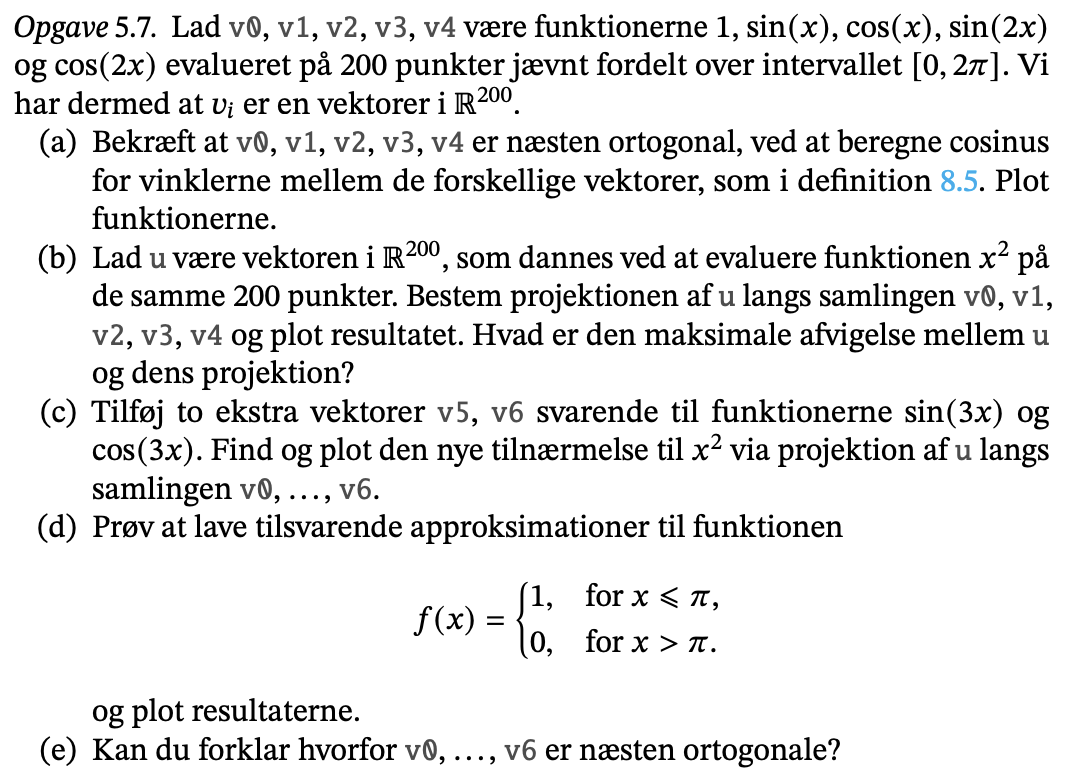

## (a)

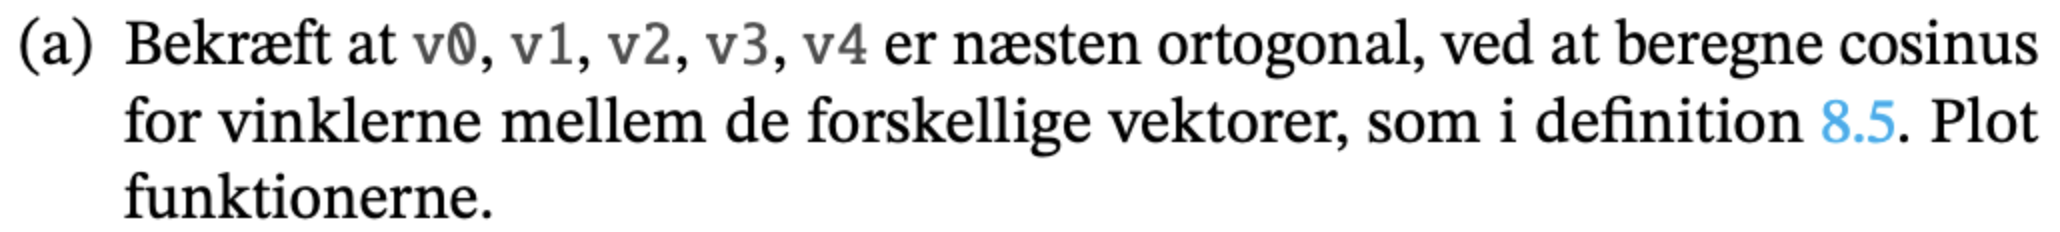

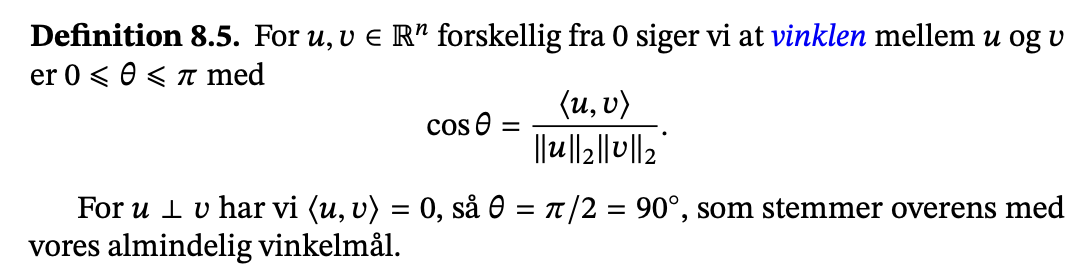

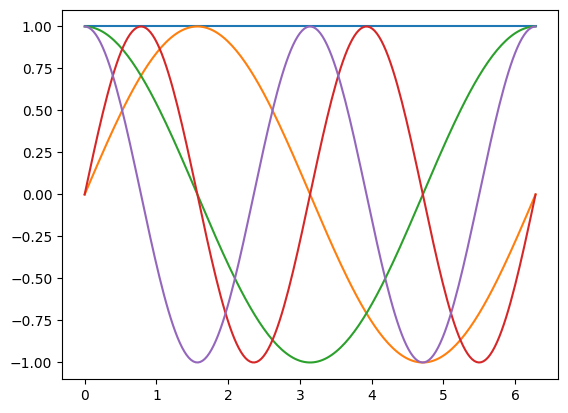

In [321]:
x = np.linspace(0, 2*np.pi, 200)
v0 = np.ones(200) [:, np.newaxis]
v1 = np.sin(x) [:, np.newaxis]
v2 = np.cos(x) [:, np.newaxis]
v3 = np.sin(2*x) [:, np.newaxis]
v4 = np.cos(2*x) [:, np.newaxis]

vectors = [v0, v1, v2, v3, v4]

fig, ax = plt.subplots()

for v in vectors:
    ax.plot(x, v)

In [322]:
# Vinklen mellem de 5 vektorer beregnes

for i in range(5):
    v = vectors[i]
    for j in range(i, 5):
        u = vectors[j]
        if not np.allclose(u, v):
            print(np.vdot(u, v)/(np.linalg.norm(u)*np.linalg.norm(v)))

1.4301560654917783e-17
0.0070534561585859626
-1.6060050056167346e-17
0.007053456158585932
-1.5074935444109248e-17
1.1266985390452377e-16
-5.0741295942485096e-17
-5.665677693954062e-17
0.009950248756218846
-7.806353221920785e-18


Som der kan ses ovenfor er cosinus til alle vinklerne forholdsvis tæt på $0$, hvilket vil sige at de er vinkelrette.

## (b)

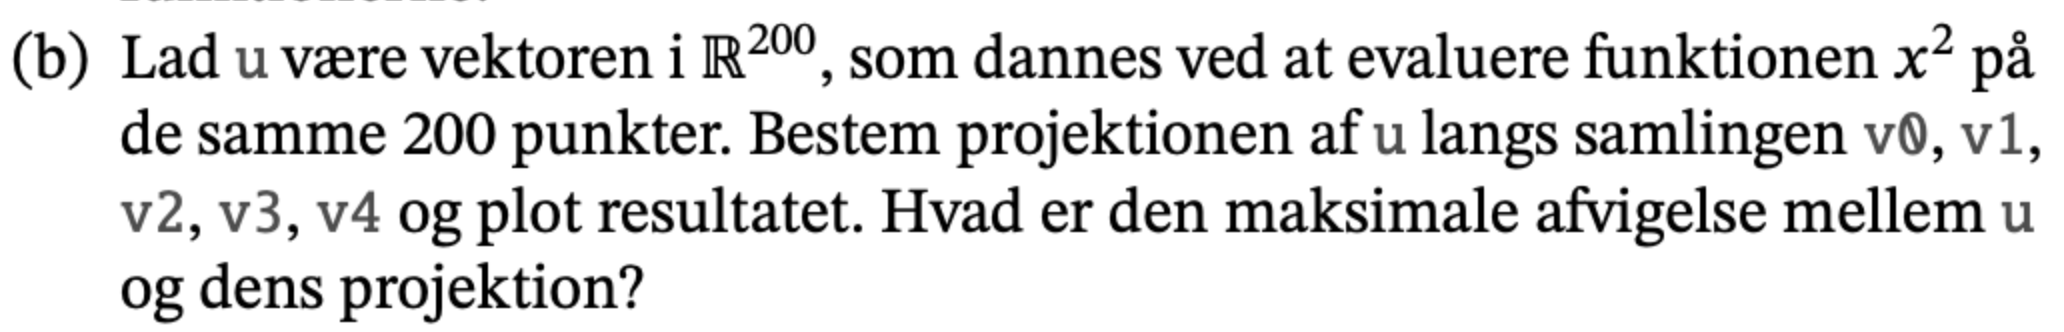

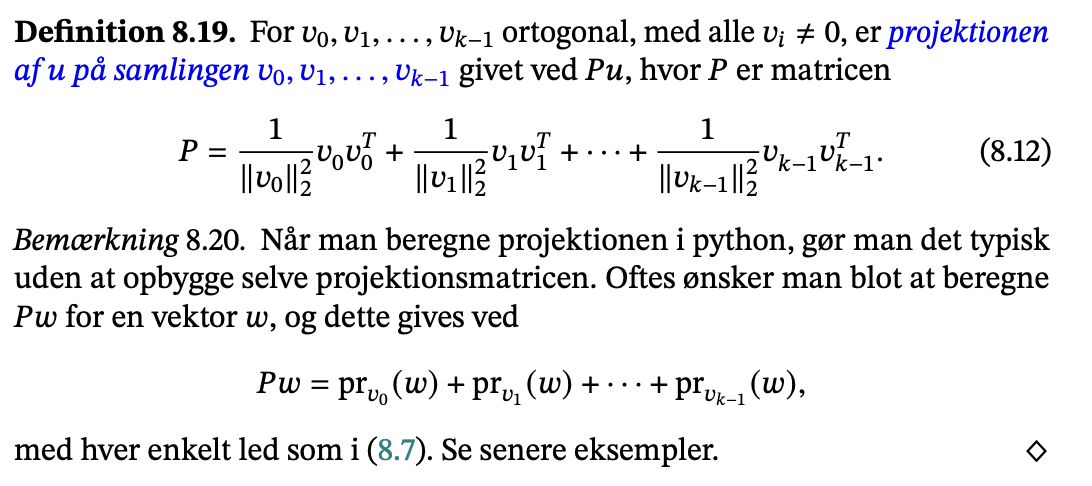

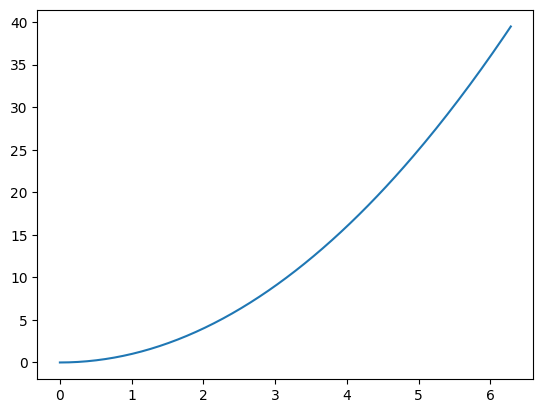

In [323]:
# Definering af u
u = x**2

fig, ax = plt.subplots()

ax.plot(x, u)

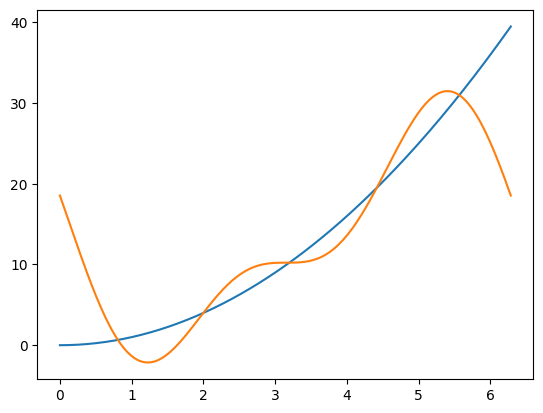

In [324]:
# Angivelse af projektionsmatrice
P = np.ndarray([200, 200])

for v in vectors:
    P += (1/np.vdot(v, v)) * v @ v.T

# Bestemmelse af projektion af u på samlingen    
uProj = P @ u

# Plot
fig, ax = plt.subplots()

ax.plot(x, u)
ax.plot(x, uProj)

## (c)

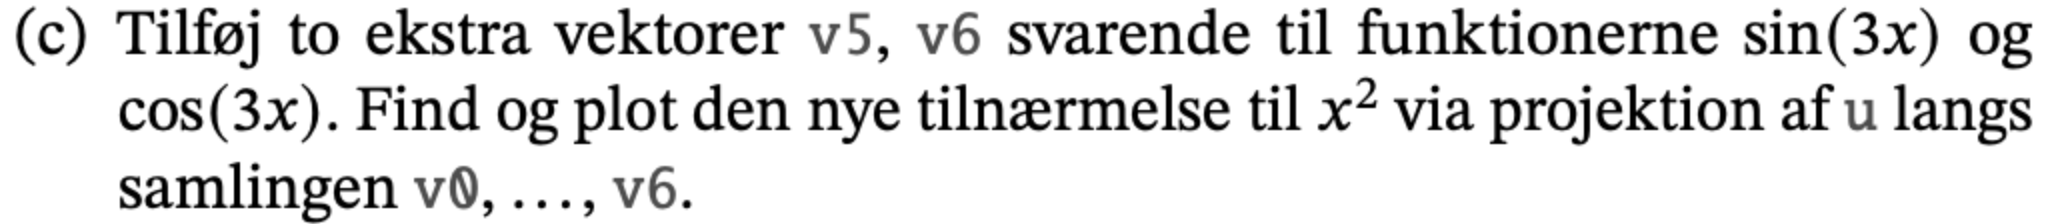

In [325]:
v5 = np.sin(3*x) [:, np.newaxis]
v6 = np.cos(3*x) [:, np.newaxis]

vectors.append(v5)
vectors.append(v6)

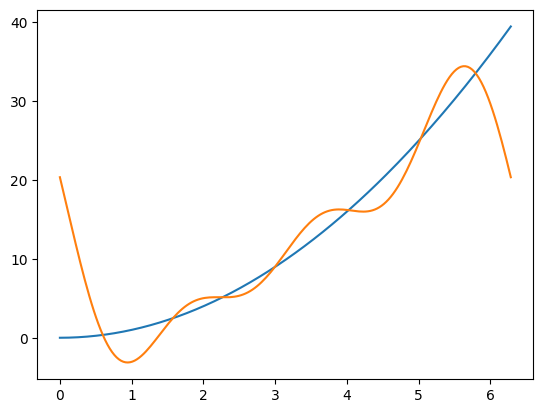

In [326]:
# Angivelse af projektionsmatrice
P = np.ndarray([200, 200])

for v in vectors:
    P += (1/np.vdot(v, v)) * v @ v.T

# Bestemmelse af projektion af u på samlingen    
uProj = P @ u

# Plot
fig, ax = plt.subplots()

ax.plot(x, u)
ax.plot(x, uProj)

## (d)

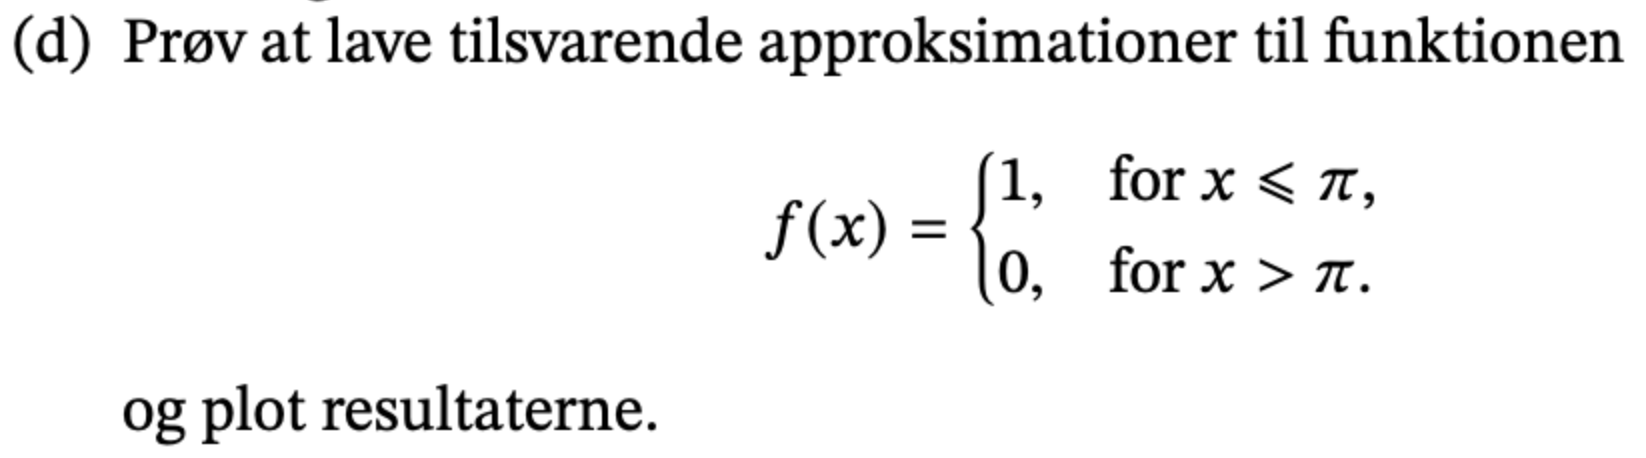

In [327]:
# Jeg angiver den nye funktion som w
w = np.linspace(0, 2* np.pi, 200)

for i in range(200):
    if w[i] <= np.pi:
        w[i] = 1
    else:
        w[i] = 0

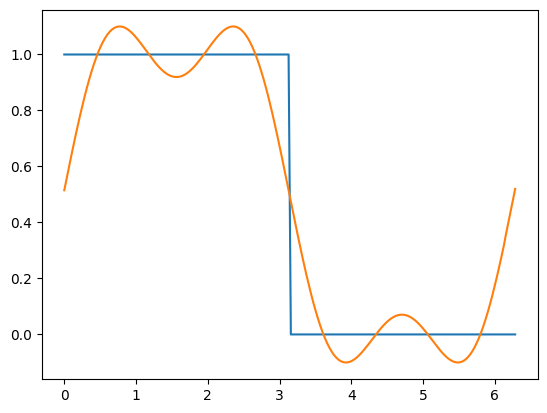

In [328]:
# Angivelse af projektionsmatrice
P = np.ndarray([200, 200])

for v in vectors:
    P += (1/np.vdot(v, v)) * v @ v.T

# Bestemmelse af projektion af u på samlingen    
wProj = P @ w

# Plot
fig, ax = plt.subplots()

ax.plot(x, w)
ax.plot(x, wProj)

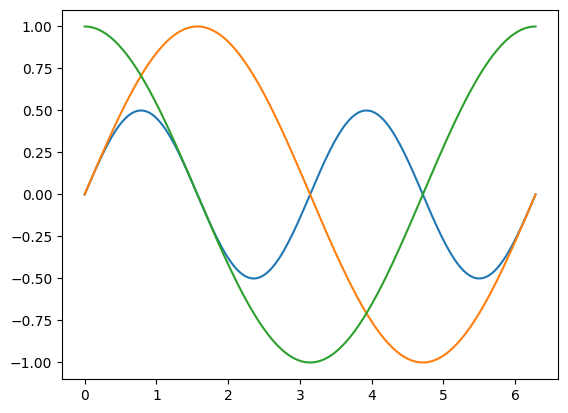

In [329]:
fig, bx = plt.subplots()

bx.plot(x, v1 * v2 )
bx.plot(x, v1 )
bx.plot(x, v2 )

## (e)

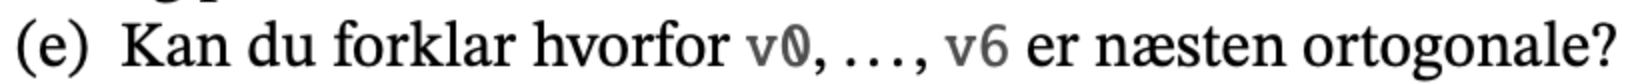

Et klart et eksempel er at der er umuligt at finde et s der får følgende til at være sandt: $\cos(x) = s * \cos(2x)$